#Import library

In [ ]:
import pandas as pd                      # Mengolah dan membaca data dalam bentuk tabel (DataFrame)

import numpy as np                       # Mengolah data numerik dan perhitungan matematika

import matplotlib.pyplot as plt           # Membuat visualisasi/grafik

from sklearn.model_selection import train_test_split
# Membagi dataset menjadi data training dan data testing

from sklearn.preprocessing import OneHotEncoder
# Mengubah data kategorikal (teks) menjadi bentuk numerik

from sklearn.compose import ColumnTransformer
# Mengatur proses preprocessing pada kolom-kolom tertentu

from sklearn.tree import DecisionTreeClassifier, plot_tree
# DecisionTreeClassifier digunakan untuk membuat model Decision Tree
# plot_tree digunakan untuk menampilkan bentuk/pohon Decision Tree

from sklearn.metrics import (
    accuracy_score,                      # Menghitung tingkat akurasi model
    classification_report,               # Menampilkan precision, recall, f1-score, dan support
    confusion_matrix,                    # Membuat tabel Confusion Matrix
    ConfusionMatrixDisplay               # Menampilkan Confusion Matrix dalam bentuk grafik
)

import joblib                            # Menyimpan dan memuat model Machine Learning

#Baca dataset

In [ ]:
df = pd.read_csv("Dataset_Sekolah_Unggul_5000_10_Atribut.csv", sep=";")
# Membaca dataset CSV dengan pemisah antar kolom berupa tanda titik koma (;)

print("Ukuran dataset:", df.shape)
# Menampilkan jumlah baris dan jumlah kolom pada dataset

df.head()
# Menampilkan 5 baris pertama untuk melihat isi dataset

Ukuran dataset: (5000, 11)


,jumlah_siswa,jumlah_guru,rasio_guru_siswa,persentase_guru_bersertifikasi,rata_rata_nilai,prestasi_akademik,akreditasi,persentase_fasilitas_layak,kehadiran_siswa,persentase_lulusan_melanjutkan,status_sekolah
0,252,11,22.91,61.52,69.10,13,B,45.00,87.22,69.46,Tidak Unggul
1,585,21,27.86,54.54,68.39,5,C,65.22,77.99,50.00,Tidak Unggul
2,420,30,14.00,98.12,84.30,16,A,70.53,93.40,76.21,Unggul
3,256,12,21.33,66.24,74.58,13,B,82.53,80.57,94.35,Tidak Unggul
4,221,10,22.10,71.37,75.20,9,C,59.22,81.75,67.33,Tidak Unggul


#Cek struktur dataset

In [ ]:
print("Nama kolom:")
# Menampilkan teks "Nama kolom:" sebagai keterangan output

print(df.columns.tolist())
# Menampilkan seluruh nama kolom yang terdapat dalam dataset
# .columns → mengambil nama-nama kolom
# .tolist() → mengubahnya menjadi bentuk list agar lebih mudah dibaca

print("\nInformasi dataset:")
# Menampilkan judul "Informasi dataset:"
# \n digunakan untuk memberikan satu baris kosong

df.info()
# Menampilkan informasi dataset, seperti:
# - jumlah data/baris
# - jumlah kolom
# - nama setiap kolom
# - jumlah data yang tidak kosong (Non-Null Count)
# - tipe data setiap kolom

print("\nJumlah data kosong:")
# Menampilkan judul untuk pemeriksaan data kosong

print(df.isnull().sum())
# Menghitung jumlah data kosong (missing value) pada setiap kolom
# isnull() → mendeteksi data yang kosong
# sum() → menghitung jumlah data kosong pada masing-masing kolom

Nama kolom:
['jumlah_siswa', 'jumlah_guru', 'rasio_guru_siswa', 'persentase_guru_bersertifikasi', 'rata_rata_nilai', 'prestasi_akademik', 'akreditasi', 'persentase_fasilitas_layak', 'kehadiran_siswa', 'persentase_lulusan_melanjutkan', 'status_sekolah']

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   jumlah_siswa                    5000 non-null   int64  
 1   jumlah_guru                     5000 non-null   int64  
 2   rasio_guru_siswa                5000 non-null   float64
 3   persentase_guru_bersertifikasi  5000 non-null   float64
 4   rata_rata_nilai                 5000 non-null   float64
 5   prestasi_akademik               5000 non-null   int64  
 6   akreditasi                      5000 non-null   object 
 7   persentase_fasilitas_layak      5000 non-null   float64
 8   kehad

#Cek target

In [ ]:
print("Jumlah kategori:", df["status_sekolah"].nunique())
# Menghitung jumlah kategori unik yang terdapat pada kolom status_sekolah
# nunique() digunakan untuk mengetahui banyaknya kategori yang berbeda

print("Kategori:", df["status_sekolah"].unique())
# Menampilkan semua kategori unik yang terdapat pada kolom status_sekolah
# unique() digunakan untuk melihat nilai/kategori yang berbeda

print("\nDistribusi status sekolah:")
# Menampilkan judul untuk melihat distribusi setiap kategori status sekolah
# \n digunakan untuk memberikan satu baris kosong

print(df["status_sekolah"].value_counts())
# Menghitung jumlah data pada masing-masing kategori status_sekolah
# value_counts() digunakan untuk mengetahui frekuensi setiap kategori

Jumlah kategori: 2
Kategori: ['Tidak Unggul' 'Unggul']

Distribusi status sekolah:
status_sekolah
Tidak Unggul    2500
Unggul          2500
Name: count, dtype: int64


#Tentukan X dan y

In [ ]:
X = df.drop("status_sekolah", axis=1)
# Membuat variabel X sebagai data fitur/predictor.
# Kolom "status_sekolah" dihapus karena merupakan target yang ingin diprediksi.
# axis=1 menunjukkan bahwa yang dihapus adalah kolom.

y = df["status_sekolah"]
# Membuat variabel y sebagai target/label.
# Kolom "status_sekolah" digunakan sebagai hasil yang akan diprediksi oleh model.

print("Fitur X:")
# Menampilkan keterangan bahwa bagian berikutnya adalah daftar fitur X

print(X.columns.tolist())
# Menampilkan nama-nama kolom yang digunakan sebagai fitur/predictor

print("\nTarget y:")
# Menampilkan keterangan bahwa bagian berikutnya adalah target y

print(y.name)
# Menampilkan nama kolom yang digunakan sebagai target, yaitu "status_sekolah"

Fitur X:
['jumlah_siswa', 'jumlah_guru', 'rasio_guru_siswa', 'persentase_guru_bersertifikasi', 'rata_rata_nilai', 'prestasi_akademik', 'akreditasi', 'persentase_fasilitas_layak', 'kehadiran_siswa', 'persentase_lulusan_melanjutkan']

Target y:
status_sekolah


#Pisahkan data numerik dan kategorikal

In [ ]:
kolom_kategorikal = ["akreditasi"]
# Menentukan kolom yang berisi data kategorikal (berupa kategori/teks).
# Kolom "akreditasi" berisi kategori seperti A, B, atau C.
# Kolom ini nantinya akan diproses menggunakan OneHotEncoder.

kolom_numerik = [
    "jumlah_siswa",
    "jumlah_guru",
    "rasio_guru_siswa",
    "persentase_guru_bersertifikasi",
    "rata_rata_nilai",
    "prestasi_akademik",
    "persentase_fasilitas_layak",
    "kehadiran_siswa",
    "persentase_lulusan_melanjutkan"
]
# Menentukan kolom-kolom yang berisi data numerik berupa angka.
# Data numerik dapat langsung digunakan dalam proses pemodelan.

#Encoding + preprocessing

In [ ]:
preprocessor = ColumnTransformer(
    # Membuat objek untuk mengatur proses preprocessing
    # pada kolom-kolom tertentu dalam dataset.

    transformers=[
        # Menentukan transformasi yang akan dilakukan pada data.

        (
            "kategori",
            # Nama transformasi yang diberikan, yaitu "kategori".

            OneHotEncoder(handle_unknown="ignore"),
            # Mengubah data kategorikal seperti A, B, C menjadi
            # representasi numerik menggunakan One-Hot Encoding.
            # handle_unknown="ignore" membuat program tetap berjalan
            # jika terdapat kategori baru yang tidak ditemukan saat training.

            kolom_kategorikal
            # Menentukan kolom yang akan diproses.
            # Dalam kasus ini adalah kolom "akreditasi".
        )
    ],

    remainder="passthrough"
    # Kolom lain yang tidak disebutkan dalam transformers
    # akan dibiarkan dalam bentuk aslinya.
    # Jadi kolom numerik tetap digunakan sebagai data numerik.
)

#Split data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    # Data fitur yang akan dibagi menjadi data training dan testing.

    y,
    # Data target/label yang akan dibagi menjadi data training dan testing.

    test_size=0.2,
    # Menentukan 20% data digunakan sebagai data testing.
    # Berarti 80% sisanya digunakan sebagai data training.

    random_state=42,
    # Menentukan angka acak agar pembagian data selalu sama
    # setiap kali kode dijalankan.

    stratify=y
    # Menjaga proporsi setiap kategori pada target (y)
    # agar distribusi data training dan testing tetap seimbang.
)

print("Data training:", X_train.shape)
# Menampilkan jumlah baris dan kolom pada data fitur training.

print("Data testing :", X_test.shape)
# Menampilkan jumlah baris dan kolom pada data fitur testing.

Data training: (4000, 10)
Data testing : (1000, 10)


#Transform data

In [ ]:
X_train_encoded = preprocessor.fit_transform(X_train)
# Melakukan preprocessing pada data training.
# fit → mempelajari pola/kategori dari data training.
# transform → mengubah data training sesuai aturan preprocessing.
# Kolom "akreditasi" diubah menggunakan OneHotEncoder,
# sedangkan kolom numerik tetap dipertahankan.
# Hasil preprocessing disimpan dalam X_train_encoded.


X_test_encoded = preprocessor.transform(X_test)
# Melakukan preprocessing pada data testing menggunakan
# aturan yang SUDAH dipelajari dari data training.
# Pada data testing hanya menggunakan transform(), bukan fit_transform().
# Hal ini dilakukan agar tidak terjadi data leakage.


print("Ukuran X_train:", X_train_encoded.shape)
# Menampilkan jumlah baris dan kolom setelah preprocessing
# pada data training.


print("Ukuran X_test :", X_test_encoded.shape)
# Menampilkan jumlah baris dan kolom setelah preprocessing
# pada data testing.

Ukuran X_train: (4000, 12)
Ukuran X_test : (1000, 12)


#Buat Decision Tree

In [ ]:
model = DecisionTreeClassifier(
    # Membuat model klasifikasi menggunakan algoritma Decision Tree.

    criterion="entropy",
    # Menentukan metode yang digunakan untuk mengukur kualitas pembagian data.
    # "entropy" digunakan untuk menghitung tingkat ketidakpastian (impurity)
    # dan menentukan fitur terbaik untuk membuat percabangan pohon.
    # Dalam Decision Tree, entropy berkaitan dengan perhitungan Information Gain.

    max_depth=5,
    # Menentukan kedalaman maksimum pohon keputusan sebanyak 5 tingkat.
    # Pembatasan kedalaman membantu mencegah model terlalu kompleks
    # dan mengurangi risiko overfitting.

    random_state=42
    # Menentukan nilai acak agar hasil pembuatan model
    # dapat direproduksi atau tetap sama ketika kode dijalankan kembali.
)


model.fit(X_train_encoded, y_train)
# Melatih (training) model menggunakan:
# X_train_encoded → fitur/data input yang sudah melalui preprocessing
# y_train         → target/label dari data training
#
# Pada tahap ini Decision Tree mempelajari pola hubungan
# antara atribut sekolah dengan status_sekolah.


print("Model Decision Tree berhasil dibuat!")
# Menampilkan pesan bahwa proses training model telah selesai.

Model Decision Tree berhasil dibuat!


#Prediksi

In [ ]:
y_pred = model.predict(X_test_encoded)
# Menggunakan model Decision Tree yang sudah dilatih
# untuk memprediksi status sekolah berdasarkan data testing.
# X_test_encoded = data fitur testing yang sudah melalui preprocessing.
# Hasil prediksi disimpan ke dalam variabel y_pred.

print("Prediksi selesai!")
# Menampilkan pesan bahwa proses prediksi telah selesai.

print(y_pred[:20])
# Menampilkan 20 hasil prediksi pertama dari seluruh data testing.
# [:20] berarti mengambil data dari indeks 0 sampai 19.

Prediksi selesai!
['Tidak Unggul' 'Unggul' 'Tidak Unggul' 'Unggul' 'Unggul' 'Unggul'
 'Unggul' 'Unggul' 'Tidak Unggul' 'Tidak Unggul' 'Unggul' 'Tidak Unggul'
 'Tidak Unggul' 'Tidak Unggul' 'Tidak Unggul' 'Tidak Unggul' 'Unggul'
 'Tidak Unggul' 'Unggul' 'Unggul']


#Evaluasi

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
# Menghitung tingkat akurasi model dengan membandingkan:
# y_test → status sekolah yang sebenarnya
# y_pred → status sekolah hasil prediksi model
# Hasilnya berupa nilai antara 0 sampai 1.

print("Accuracy:", accuracy)
# Menampilkan nilai akurasi model.
# Contoh: 0.95 berarti 95% prediksi model benar.

print("\nClassification Report:")
# Menampilkan judul untuk hasil evaluasi klasifikasi.
# \n digunakan untuk memberikan satu baris kosong.

print(classification_report(y_test, y_pred))
# Menampilkan laporan performa model yang terdiri dari:
# - precision → ketepatan prediksi suatu kelas
# - recall    → kemampuan model menemukan data suatu kelas
# - f1-score  → gabungan antara precision dan recall
# - support   → jumlah data sebenarnya pada setiap kelas

Accuracy: 0.893

Classification Report:
              precision    recall  f1-score   support

Tidak Unggul       0.88      0.91      0.89       500
      Unggul       0.91      0.87      0.89       500

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



#Confusion Matrix

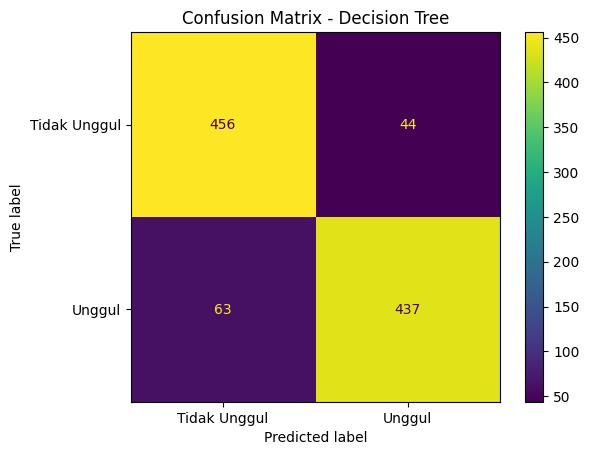

In [ ]:
cm = confusion_matrix(y_test, y_pred)
# Membuat Confusion Matrix dengan membandingkan:
# y_test → nilai/status sekolah yang sebenarnya
# y_pred → nilai/status sekolah hasil prediksi model
#
# Hasilnya berupa matriks yang menunjukkan jumlah prediksi
# benar dan salah untuk setiap kelas.


disp = ConfusionMatrixDisplay(
    # Membuat objek untuk menampilkan Confusion Matrix secara visual.

    confusion_matrix=cm,
    # Memasukkan hasil Confusion Matrix yang sudah dibuat sebelumnya.

    display_labels=model.classes_
    # Menampilkan nama kelas pada sumbu Confusion Matrix.
    # model.classes_ berisi kategori target yang dipelajari model,
    # misalnya "Unggul" dan "Tidak Unggul".
)


disp.plot()
# Mengubah Confusion Matrix menjadi tampilan grafik.


plt.title("Confusion Matrix - Decision Tree")
# Memberikan judul pada grafik.


plt.show()
# Menampilkan grafik Confusion Matrix.

#Visualisasi Decision Tree

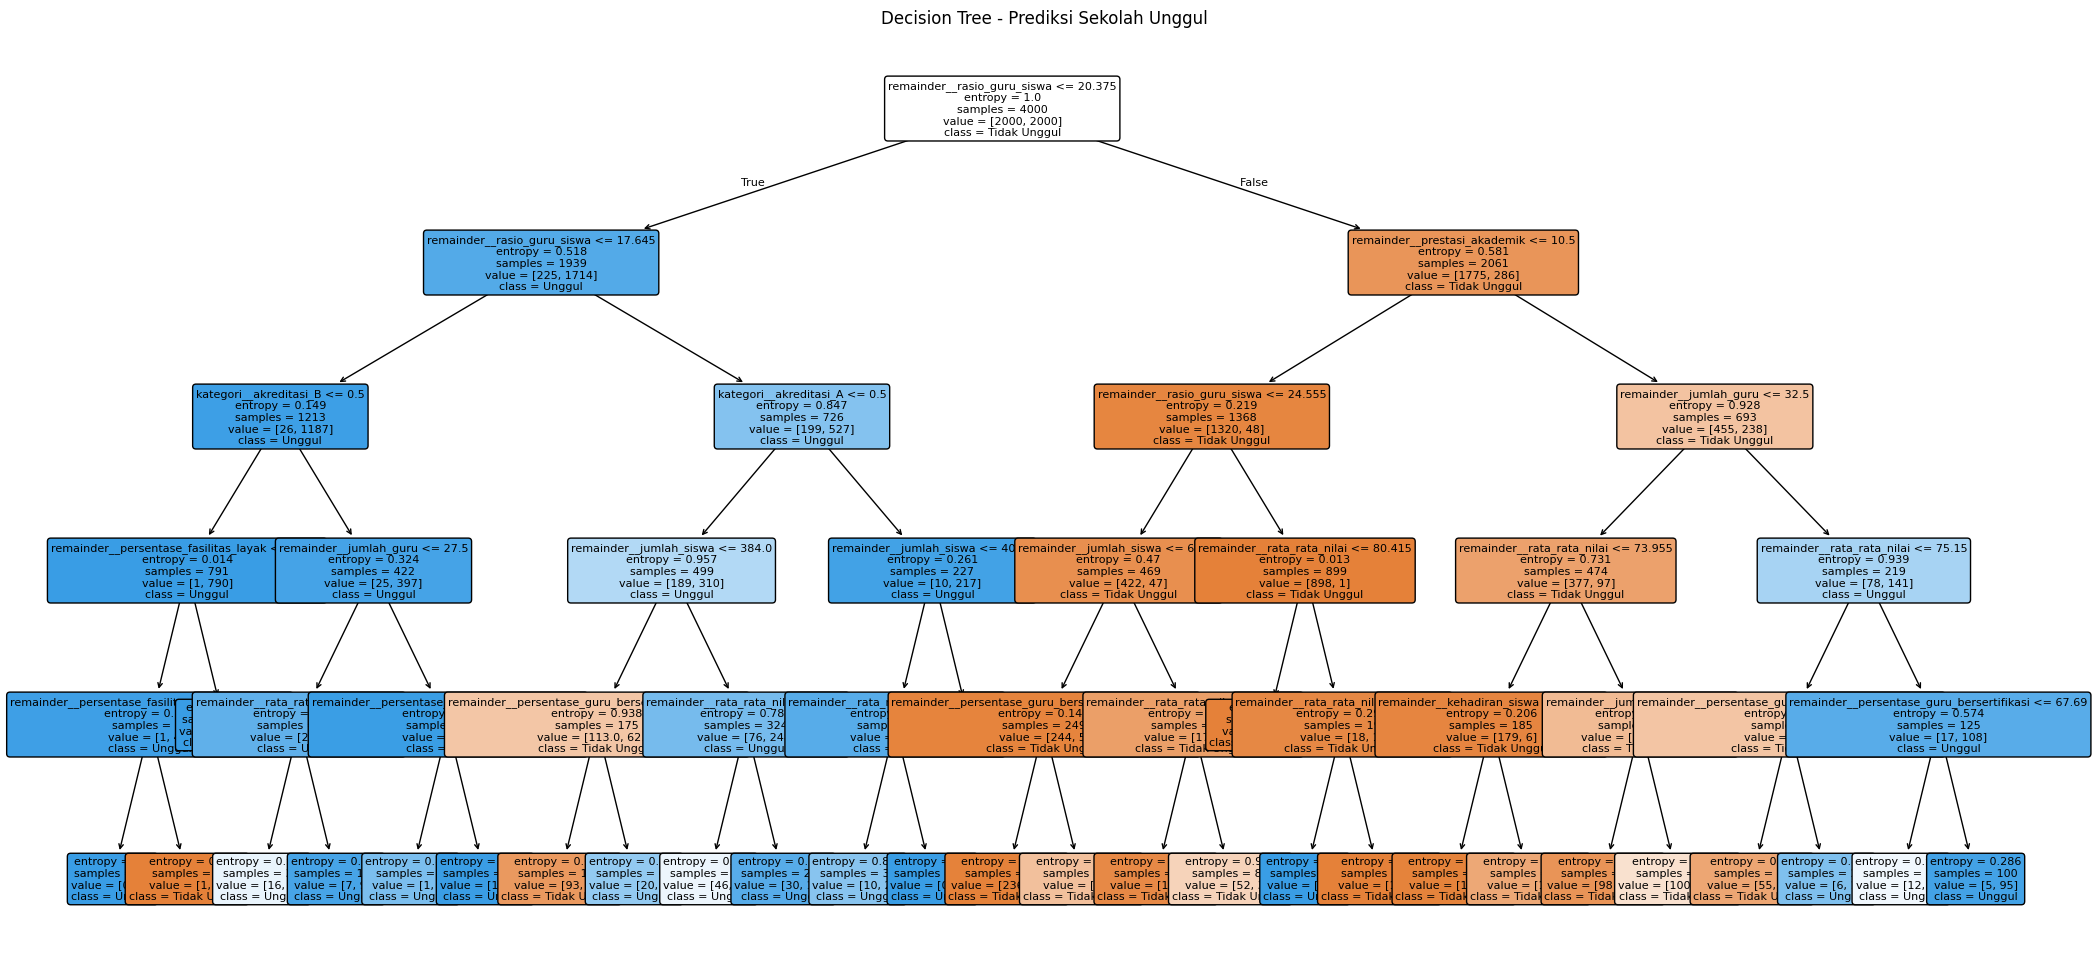

In [ ]:
feature_names = preprocessor.get_feature_names_out()
# Mengambil nama fitur setelah proses preprocessing.
# Karena kolom "akreditasi" sudah diubah menggunakan OneHotEncoder,
# nama fitur bisa berubah, misalnya:
# akreditasi_A, akreditasi_B, akreditasi_C.
#
# Nama fitur ini diperlukan agar setiap percabangan pada pohon
# memiliki nama atribut yang jelas.


plt.figure(figsize=(25, 12))
# Membuat area gambar dengan ukuran:
# lebar = 25
# tinggi = 12
# Ukuran besar digunakan agar struktur pohon lebih mudah dibaca.


plot_tree(
    model,
    # Menampilkan struktur Decision Tree yang sudah dilatih.

    feature_names=feature_names,
    # Memberikan nama fitur pada setiap percabangan pohon.

    class_names=model.classes_,
    # Menampilkan nama kelas/target pada setiap node,
    # misalnya "Unggul" dan "Tidak Unggul".

    filled=True,
    # Memberikan warna pada setiap node berdasarkan kelas
    # yang dominan pada node tersebut.

    rounded=True,
    # Membuat bentuk kotak/node pada pohon menjadi lebih membulat
    # agar tampilan lebih mudah dibaca.

    fontsize=8
    # Mengatur ukuran tulisan pada setiap node menjadi 8.
)


plt.title("Decision Tree - Prediksi Sekolah Unggul")
# Memberikan judul pada visualisasi Decision Tree.


plt.show()
# Menampilkan gambar/pohon Decision Tree.

#Simpan model

In [ ]:
import joblib
# Mengimpor library joblib yang digunakan untuk menyimpan
# dan memuat objek Python, termasuk model Machine Learning.


joblib.dump(model, "decision_tree_sekolah.joblib")
# Menyimpan model Decision Tree yang sudah selesai dilatih
# ke dalam file bernama "decision_tree_sekolah.joblib".
# File ini berisi model yang sudah mempelajari pola dari dataset.


joblib.dump(preprocessor, "preprocessor_sekolah.joblib")
# Menyimpan preprocessor yang sebelumnya digunakan untuk mengubah
# data kategorikal menjadi numerik.
#
# Preprocessor harus disimpan agar data baru di Streamlit
# diproses dengan cara yang sama seperti saat training.


print("Model dan preprocessor berhasil disimpan!")
# Menampilkan pesan bahwa model dan preprocessor
# berhasil disimpan.

Model dan preprocessor berhasil disimpan!


In [ ]:
import os
# Mengimpor library os yang digunakan untuk berinteraksi dengan
# sistem operasi, termasuk melihat file dan folder.


print(os.listdir())
# Menampilkan daftar file dan folder yang terdapat
# pada direktori/folder kerja saat ini.
#
# Digunakan untuk memastikan file hasil training
# sudah berhasil tersimpan.

['.config', 'decision_tree_sekolah.joblib', 'Dataset_Sekolah_Unggul_5000_10_Atribut.csv', 'preprocessor_sekolah.joblib', 'sample_data']


**Penjelasan Decision Tree**

Decision Tree adalah algoritma Machine Learning yang digunakan untuk melakukan klasifikasi. Pada penelitian ini, Decision Tree digunakan untuk memprediksi status sekolah, yaitu Unggul atau Tidak Unggul berdasarkan beberapa atribut seperti jumlah siswa, jumlah guru, rasio guru dan siswa, nilai akademik, fasilitas, kehadiran siswa, lulusan yang melanjutkan pendidikan, dan akreditasi.

Data dibagi menjadi 80% data training dan 20% data testing. Data kategorikal seperti akreditasi diubah menjadi bentuk numerik menggunakan OneHotEncoder. Model Decision Tree menggunakan Entropy untuk menentukan percabangan terbaik berdasarkan Information Gain dan menggunakan max_depth=5 untuk mengurangi risiko overfitting.

Setelah model dilatih, dilakukan prediksi pada data testing. Performa model kemudian dievaluasi menggunakan Accuracy, Classification Report, dan Confusion Matrix.